# Signalling synapses using the volume transmitter

The volume transmitter can be used to send discrete signals to synapses, such as "update your weight with a random increment" or "undo the last change and go back to the previous weight". This uses the "multiplicity" event attribute in NEST Simulator.

In [21]:
%matplotlib inline

from typing import List, Optional

import matplotlib as mpl

mpl.rcParams["axes.formatter.useoffset"] = False
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "k"
mpl.rcParams["grid.linestyle"] = ":"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["figure.figsize"] = [8., 3.]

import matplotlib.pyplot as plt
import nest
import numpy as np
import os
import random
import re
import time

from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils
from pynestml.codegeneration.nest_tools import NESTTools

DEBUG:Loaded backend module://matplotlib_inline.backend_inline version unknown.


## Generating code with NESTML

To generate fast code, NESTML needs to process the synapse model together with the neuron model that will be its postsynaptic partner in the network instantiantion (see https://nestml.readthedocs.io/en/latest/nestml_language/synapses_in_nestml.html#generating-code).

In this tutorial, we will use a very simple integrate-and-fire model, where arriving spikes cause an instantaneous increment of the membrane potential, the "iaf_psc_delta" model.

When NESTML is invoked, the C++ code is generated for the models, and then built (compiled) as a NEST extension module, which is then loaded into the NEST kernel at runtime using ``nest.Install()``.

The resulting neuron and synapse model names are returned by the function, because when generating code for plastic synapses, there is typically a tight integration of the generated with code with that of the postsynaptic neuron model. For more information about this, please see the NESTML documentation section [Generating code for plastic synapses](https://nestml.readthedocs.io/en/latest/running/running_nest.html#generating-code-for-plastic-synapses). Hence, the resulting model names are composed of associated neuron and synapse partners, because of the co-generation, for example, ``"stdp_synapse__with_iaf_psc_delta"`` and ``"iaf_psc_delta__with_stdp_synapse"``.

### Formulating the model in NESTML

We now go on to define the full synapse model in NESTML:

In [2]:
nestml_stdp_dopa_model = """
model jump_and_reset_synapse:

    state:
        w real = 1.
        w_prev real = 1.

    input:
        pre_spikes <- spike
        mod_spikes <- spike

    output:
        spike

    onReceive(mod_spikes):
        println("mod_spikes multiplicity = {mod_spikes}")
        if mod_spikes == 1:
            # this is the signal for: add a random increment to the weight
            w_prev = w
            w += random_normal(0, 1)
        else:
            # this is the signal for: go back to the previous weight
            w = w_prev

    onReceive(pre_spikes):
        # deliver spike to postsynaptic partner
        emit_spike(w)
"""

Generate the code, build the user module and make the model available to instantiate in NEST:

In [3]:
# generate and build code
module_name, neuron_model_name, synapse_model_name = \
    NESTCodeGeneratorUtils.generate_code_for("../../../models/neurons/iaf_psc_delta_neuron.nestml",
                                             nestml_stdp_dopa_model,
                                             mod_ports=["mod_spikes"],
                                             logging_level="DEBUG",
                                             codegen_opts={"weight_variable": {"jump_and_reset_synapse": "w"}})

[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /home/charl/julich/nestml-upstream/nestml/doc/tutorials/stdp_dopa_synapse/../../../models/neurons/iaf_psc_delta_neuron.nestml
[3,GLOBAL, INFO]: /home/charl/julich/nestml-upstream/nestml/doc/tutorials/stdp_dopa_synapse/neuromodulated_stdp_synapse.nestml
[4,GLOBAL, INFO]: Target platform code will be generated in directory: "/home/charl/julich/nestml-upstream/nestml/doc/tutorials/stdp_dopa_synapse/target"
[5,GLOBAL, INFO]: Target platform code will be installed in directory: "/tmp/nestml_target_k3ibnwk_"

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : May  7 2026 23:17:50

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[6,GLOBAL, INFO]: The NEST Simulator version was automatically detected as:

INFO:Analysing input:
INFO:{
    "dynamics": [
        {
            "expression": "V_m' = (-(V_m - E_L)) / tau_m + unit_psp * 0 * (1 / 1.0) + (I_e + I_stim) / C_m",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "refr_t' = (-1000.0) * 1.0 / 1000.0",
            "initial_values": {
                "refr_t": "0"
            }
        }
    ],
    "options": {
        "output_timestep_symbol": "__h",
        "simplify_expression": "sympy.logcombine(sympy.powsimp(sympy.expand(expr)))"
    },
    "parameters": {
        "C_m": "250",
        "E_L": "(-70)",
        "I_e": "0",
        "V_reset": "(-70)",
        "V_th": "(-55)",
        "refr_T": "2",
        "tau_m": "10"
    }
}
INFO:Processing global options...
INFO:Processing input shapes...
DEBUG:
Processing differential-equation form shape V_m with defining expression = "(-(V_m - E_L)) / tau_m + unit_psp * 0 * (1 / 1.0) + (I_e + I_stim) / C_m"
DEBUG:Splitting 

[15,GLOBAL, INFO]: State variables that will be moved from synapse to neuron: []
[16,GLOBAL, INFO]: Parameters that will be copied from synapse to neuron: []
[17,GLOBAL, INFO]: Synaptic state variables moved to neuron that will need buffering: []
[18,GLOBAL, INFO]: In synapse: replacing ``continuous`` type input ports that are connected to postsynaptic neuron with external variable references
[19,GLOBAL, INFO]: Copying parameters from synapse to neuron...
[20,GLOBAL, INFO]: Adding suffix to variables in spike updates
[21,GLOBAL, INFO]: In synapse: replacing variables with suffixed external variable references
[22,GLOBAL, INFO]: Successfully constructed neuron-synapse pair iaf_psc_delta_neuron_nestml__with_neuromodulated_stdp_synapse_nestml, neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml


DEBUG:	Returning shape: Shape "V_m" of order 1
DEBUG:
Processing differential-equation form shape refr_t with defining expression = "(-1000.0) * 1.0 / 1000.0"
DEBUG:Splitting expression -1.00000000000000 (symbols [V_m, refr_t, V_m, refr_t])
DEBUG:	linear factors: Matrix([[0], [0], [0], [0]])
DEBUG:	inhomogeneous term: -1.00000000000000
DEBUG:	nonlinear term: 0.0
DEBUG:Created Shape with symbol refr_t, derivative_factors = [0], inhom_term = -1.00000000000000, nonlin_term = 0
DEBUG:	Returning shape: Shape "refr_t" of order 1
DEBUG:Shape V_m: reconstituting expression E_L/tau_m - V_m/tau_m + I_e/C_m + I_stim/C_m
DEBUG:Splitting expression E_L/tau_m - V_m/tau_m + I_e/C_m + I_stim/C_m (symbols Matrix([[V_m], [refr_t]]))
DEBUG:	linear factors: Matrix([[-1/tau_m], [0]])
DEBUG:	inhomogeneous term: E_L/tau_m + I_e/C_m + I_stim/C_m
DEBUG:	nonlinear term: 0.0
DEBUG:Shape refr_t: reconstituting expression -1.00000000000000
DEBUG:Splitting expression -1.00000000000000 (symbols Matrix([[V_m], [refr_

DEBUG:	nonlinear term: 0.0
DEBUG:Shape refr_t: reconstituting expression -1.00000000000000
DEBUG:Splitting expression -1.00000000000000 (symbols Matrix([[V_m], [refr_t]]))
DEBUG:	linear factors: Matrix([[0], [0]])
DEBUG:	inhomogeneous term: -1.00000000000000
DEBUG:	nonlinear term: 0.0
DEBUG:Initializing system of shapes with x = Matrix([[V_m], [refr_t]]), A = Matrix([[-1/tau_m, 0], [0, 0]]), b = Matrix([[E_L/tau_m + I_e/C_m + I_stim/C_m], [-1.00000000000000]]), c = Matrix([[0], [0]])
INFO:Finding analytically solvable equations...
INFO:Saving dependency graph plot to /tmp/ode_dependency_graph.dot
DEBUG:os.makedirs('/tmp')
DEBUG:write lines to '/tmp/ode_dependency_graph.dot'
DEBUG:run [PosixPath('dot'), '-Kdot', '-Tpdf', '-O', 'ode_dependency_graph.dot']
DEBUG:Shape V_m: reconstituting expression E_L/tau_m - V_m/tau_m + I_e/C_m + I_stim/C_m
DEBUG:Splitting expression E_L/tau_m - V_m/tau_m + I_e/C_m + I_stim/C_m (symbols [V_m, refr_t])
DEBUG:	linear factors: Matrix([[-1/tau_m], [0]])
DEB

[23,GLOBAL, INFO]: Starting code generation for model "iaf_psc_delta_neuron_nestml"
[24,iaf_psc_delta_neuron_nestml, INFO, [60:0;103:0]]: Starts processing of the model "iaf_psc_delta_neuron_nestml"
[25,GLOBAL, INFO]: Starting code generation for model "iaf_psc_delta_neuron_nestml__with_neuromodulated_stdp_synapse_nestml"
[26,iaf_psc_delta_neuron_nestml__with_neuromodulated_stdp_synapse_nestml, INFO, [60:0;103:0]]: Starts processing of the model "iaf_psc_delta_neuron_nestml__with_neuromodulated_stdp_synapse_nestml"
[27,GLOBAL, INFO]: Analysing/transforming synapse neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml.
[28,neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml, INFO, [2:0;27:0]]: Starts processing of the model "neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml"
[29,GLOBAL, INFO]: Rendering template /home/charl/julich/nestml-upstream/nestml/doc/tutorials/stdp_dopa_synapse/target/iaf_psc_delta_neuron_nestml.cpp
[30,GLOBAL, I

## Running the simulation in NEST

Let's define a function that will instantiate a simple network with one presynaptic cell and one postsynaptic cell connected by a single synapse, then run a simulation and plot the results.



In [31]:
def run_network(pre_spike_times,
                vt_spike_times,
                neuron_model_name,
                synapse_model_name,
                resolution=.1, # [ms]
                delay=1., # [ms]
                sim_time=None,  # if None, computed from pre and post spike times
                synapse_parameters=None,  # optional dictionary passed to the synapse
                fname_snip="",
                debug=False):

    nest.ResetKernel()
    system_seed = int(time.time())
    nest.rng_seed = system_seed
    NESTTools.set_nest_verbosity("ERROR")
    nest.print_time = False
    nest.Install(module_name)
    nest.resolution = resolution

    # create spike_generators with these times
    pre_sg = nest.Create("spike_generator",
                         params={"spike_times": pre_spike_times})
    vt_sg = nest.Create("spike_generator",
                        params={"spike_times": vt_spike_times})
    #,
    #                           "spike_weights": [1, 2, 1, 2, 1, 2, 1, 2, 1]}) # XXXXXXXXXXXXXXXXXX

    # create  volume transmitter
    vt = nest.Create("volume_transmitter")
    vt_parrot = nest.Create("parrot_neuron")
    nest.Connect(vt_sg, vt_parrot)
    nest.Connect(vt_parrot, vt, syn_spec={"synapse_model": "static_synapse",
                                          "weight": 1.,
                                          "delay": 1.})   # delay is ignored!

    # set up custom synapse models
    wr = nest.Create("weight_recorder")
    nest.CopyModel(synapse_model_name, "stdp_nestml_rec",
                   {"weight_recorder": wr[0],
                    "w": 1.,
                    "delay": delay,
                    "receptor_type": 0,
                    "volume_transmitter": vt})

    # create parrot neurons and connect spike_generators
    pre_neuron = nest.Create("parrot_neuron")
    post_neuron = nest.Create(neuron_model_name)
    
    spikedet_pre = nest.Create("spike_recorder")
    spikedet_vt = nest.Create("spike_recorder")

    #mm = nest.Create("multimeter", params={"record_from" : ["V_m"]})

    nest.Connect(pre_sg, pre_neuron, "one_to_one", syn_spec={"delay": 1.})
#     nest.Connect(post_sg, post_neuron, "one_to_one", syn_spec={"delay": 1., "weight": 9999.})
    nest.Connect(pre_neuron, post_neuron, "all_to_all", syn_spec={"synapse_model": "stdp_nestml_rec"})

    nest.Connect(pre_neuron, spikedet_pre)
#     nest.Connect(post_neuron, spikedet_post)
    nest.Connect(vt_parrot, spikedet_vt)
    
    # get STDP synapse and weight before protocol
    syn = nest.GetConnections(source=pre_neuron, synapse_model="stdp_nestml_rec")
    if synapse_parameters is None:
        synapse_parameters = {}
    nest.SetStatus(syn, synapse_parameters)

    sim_time = np.amax(pre_spike_times) + 1.
    times = []
    weights = []
    while nest.biological_time < sim_time:
        nest.Simulate(nest.resolution)
        times.append(nest.biological_time)
        weights.append(syn.w)

    pre_spike_times_ = nest.GetStatus(spikedet_pre, "events")[0]["times"]
    vt_spike_times_ = nest.GetStatus(spikedet_vt, "events")[0]["times"]

    return times, weights#wr.events["times"], wr.events["weights"]

[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 1
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 2
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 3
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 4
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 5
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_d

[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 59
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
@@@@@@@@@@@@@@@@ in static_synapse multiplicity = 1
@@@@@@@@@@@@@@@@ in static_synapse multiplicity = 1
[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 60
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
[synapse 0x5b75a60] neuromodulated_stdp_synapse_nestml__with_iaf_psc_delta_neuron_nestml::trigger_update_weight(): t = 61
	 aaa vt_spike multiplicity = 0
	 bbbb vt_spike multiplicity = 0
@@@@@@@@@@@@@@@@ in static_synapse multiplicity = 2
@@@@@@@@@@@@@@@@ in static_synapse multiplicity = 1
nest::volume_transmitter::handle: multiplicity = 1
@@@@@@@@@@@@@@@@ in static_synapse multiplicity = 1
nest::volume_transmitter::handle: multiplicity = 1
nest::volume_transmitter::update: multiplicity = 2
[synapse 0x5b75a60] neurom

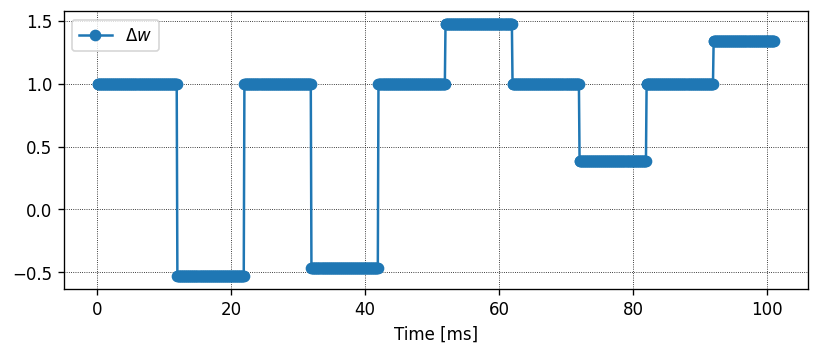

In [33]:
pre_spike_times = [100.] #np.linspace(10, 100, 10)
vt_spike_times = [10., 20., 20., 30., 40., 40., 50., 60., 60., 70., 80, 80., 90.]

timevec, dw = run_network(pre_spike_times,
                vt_spike_times,
                neuron_model_name,
                synapse_model_name)

fig, ax = plt.subplots()
ax.plot(timevec, dw, marker="o", label="$\\Delta w$")
ax.set_xlabel("Time [ms]")
ax.legend()
plt.show()
plt.close(fig)

Acknowledgements
----------------

This software was developed in part or in whole in the Human Brain Project, funded from the European Union’s Horizon 2020 Framework Programme for Research and Innovation under Specific Grant Agreements No. 720270, No. 785907 and No. 945539 (Human Brain Project SGA1, SGA2 and SGA3).

The authors would like to thank Moritz Helias for suggestions and support.


License
-------

This notebook (and associated files) is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 2 of the License, or (at your option) any later version.

This notebook (and associated files) is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.